# Tech Challenge — Fase 1 | Case NPS Preditivo
## Notebook de Análise Exploratória (EDA) — Estrutura CRISP-DM

**Pós Tech em Data Science (AI Scientist) — FIAP**  
**Grupo:** (61)
**Data:** (10/04/2026)
**Versão do Python**

---

Este notebook segue a metodologia **CRISP-DM** (Cross-Industry Standard Process for Data Mining), que organiza projetos de ciência de dados em seis fases interligadas:

1. **Business Understanding** Entendimento do problema de negócio
2. **Data Understanding** Primeira inspeção dos dados
3. **Data Preparation** Limpeza e preparação
4. **Modeling** Construção do modelo preditivo (etapa opcional do case)
5. **Evaluation** Avaliação dos resultados
6. **Deployment** Proposta de uso prático na empresa

> **Convenção de nomes:** `snake_case` para variáveis e funções, `UPPER_CASE` para constantes.
- **Comentários explicam o *porquê*, não o *o quê*.


---
## 0. Business Understanding

### 0.1 Problema de negócio
O e-commerce enfrenta alta variabilidade no NPS e precisa transformar esse indicador reativo em preditivo, antecipando clientes com risco de se tornarem detratores.

### 0.2 Perguntas que este notebook busca responder (IDENTIFICAR E COMENTAR NO CÓDIGO AS RESPOSTAS)
- Quais fatores operacionais mais impactam a satisfação do cliente?
- O que mais gera detratores?
- Existe um ponto de ruptura na experiência (ex.: atraso a partir de X dias)?
- Que perfil de cliente tende a ter NPS mais alto ou mais baixo?

### 0.3 Variável-alvo (target)
A variável que representa diretamente a satisfação do cliente no dataset é o campo nps_score, uma nota de 0 a 10 atribuída pelo próprio cliente após a experiência de compra. Seguindo a metodologia clássica do Net Promoter Score, essa nota pode ser traduzida em três segmentos: detratores (0 a 6), neutros (7 ou 8) e promotores (9 ou 10).
- Tipo da variável Target `nps_score`.
- ** Quantitativa (Numérica) Discreta, no formato que assume notas de 0 a 10 (contagem que assume valor inteiro).
- ** Qualitativa (Categórica) Ordinal, no formato de ordenadas Detratores, Neutros e Promotores Representam uma hierarquia de satisfação.
- ** A partir da variável target no formato original da base de dados (quantitativa discreta, notas de 0 a 10), foi criada uma variável qualitativa ordinal, classificando os clientes em detratores, neutros e promotores, conforme a metodologia NPS padrão.
- **Segmentação NPS padrão:** Detratores (0–6), Neutros (7–8), Promotores (9–10)
- **Abordagem escolhida para o modelo :** O problema de negócio que está sendo resolvido é antecipar clientes com risco de se tornar detratores. Na avaliação realizada da Base de dados, identificamos que temos juma variável target e que existem as possibilidades de se abordar como modelo de regressão (tipo quantitativa discreta) ou classifucação (tipo qualitativa ordinal).  
******************ALINHAR DEFINIÇÃO DE MODELO E COMENTÁRIOS_(definir com o grupo — regressão / classificação binária / classificação multiclasse)_*****

### 0.4 Critérios de sucesso
- Identificar ao menos 3 drivers operacionais estatisticamente relevantes.
- Produzir insights acionáveis traduzíveis em recomendações de negócio.
- (Opcional) Entregar modelo baseline com métrica de performance adequada.

## 1. Setup Importações e configurações globais

Foram adicionadas duas possíveis metodologias para extração dos dados. Deliberadamente, disponibilizamos um ambiente virtual (venv) contendo as bibliotecas necessárias previamente instaladas para facilitar a análise. Além disso, foi definido um caminho relativo para acesso ao conteúdo em um ambiente como o Google Colab.

In [110]:
# Bibliotecas utilizadas

# Manipulação e análise de dados
import pandas as pd

# Computação numérica
import numpy as np

# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Modelagem e avaliação
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Utilitários
import warnings


---
## 2. Data Understanding

Primeira inspeção da base: volume, tipos, valores ausentes e distribuição inicial.

### 2.1 Carga inicial dos dados de NPS


In [ ]:
# Ajustar o caminho conforme a estrutura final do repositório
# O arquivo CSV deve estar na pasta 'data' dentro do repositório
# Versão para rodar em google colab "CAMINHO_DADOS_BRUTOS = '/content/desafio_nps_fase_1.csv'"
#CAMINHO_DADOS_BRUTOS = '../data/raw/desafio_nps_fase_1.csv'

CAMINHO_DADOS_BRUTOS = '/content/desafio_nps_fase_1.csv'

df = pd.read_csv(CAMINHO_DADOS_BRUTOS)
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


### 2.2 Estrutura geral da base

In [112]:
# Informação do data frame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   str    
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64  
 14  res

O dataset possui 2500 registros e 19 variáveis.
Observa-se que:
- As variáveis numéricas estão representadas principalmente por `int64` e `float64`.
- As variáveis categóricas estão no formato `object`.
- Não há valores nulos .

In [113]:
# Estatísticas descritivas das variáveis numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,2500.0,1250.500000,721.832160,1.00,625.7500,1250.500,1875.2500,2500.00
customer_age,2500.0,43.396000,14.888487,18.00,31.0000,43.000,56.0000,69.00
customer_tenure_months,2500.0,61.322400,34.478729,1.00,31.0000,62.000,91.0000,119.00
order_id,2500.0,51250.500000,721.832160,50001.00,50625.7500,51250.500,51875.2500,52500.00
order_value,2500.0,434.259740,289.772497,7.76,220.2450,375.515,577.2900,1983.81
items_quantity,2500.0,3.470800,1.687331,1.00,2.0000,3.000,5.0000,6.00
discount_value,2500.0,29.745620,29.225603,0.02,8.8850,20.935,40.8325,230.33
payment_installments,2500.0,6.004000,3.159743,1.00,3.0000,6.000,9.0000,11.00
delivery_time_days,2500.0,8.022000,3.770411,2.00,5.0000,8.000,11.0000,14.00
delivery_delay_days,2500.0,2.187200,1.454442,0.00,1.0000,2.000,3.0000,8.00


O conjunto de dados possui 2.500 registros, sem indícios de valores ausentes nas variáveis numéricas.
De forma geral, observa-se:
- As variáveis apresentam diferentes escalas, com destaque para `order_value` e `discount_value`, que possuem maior amplitude e dispersão.
- Algumas variáveis indicam possível presença de outliers, como `order_value` e `discount_value`, devido à grande diferença entre os quartis e os valores máximos.
- A variável `nps_score` apresenta média de aproximadamente 4,38, indicando uma tendência mais próxima de clientes detratores ou neutros.
- A variável `repeat_purchase_30d` possui média baixa (~0,09), sugerindo baixa taxa de recompra no curto prazo.

In [114]:
# Dicionário de dados (conforme enunciado do case), referência rápida para idenfiticação.
dicionario_dados = {
    'customer_id':               'Identificador único do cliente',
    'order_id':                  'Identificador único do pedido',
    'customer_age':              'Idade do cliente',
    'customer_region':           'Região geográfica do cliente',
    'customer_tenure_months':    'Tempo de relacionamento (meses)',
    'order_value':               'Valor total do pedido',
    'items_quantity':            'Quantidade de itens',
    'discount_value':            'Valor de desconto aplicado',
    'payment_installments':      'Número de parcelas',
    'delivery_time_days':        'Tempo total de entrega (dias)',
    'delivery_delay_days':       'Dias de atraso na entrega',
    'freight_value':             'Valor do frete',
    'delivery_attempts':         'Número de tentativas de entrega',
    'customer_service_contacts': 'Contatos do cliente com atendimento',
    'resolution_time_days':      'Tempo de resolução (dias)',
    'complaints_count':          'Número de reclamações',
    'repeat_purchase_30d':       'Recompra em 30 dias (0/1)',
    'csat_internal_score':       'Score interno de satisfação',
    'nps_score':                 'NPS nota do cliente (0 a 10) [TARGET]',
}
pd.DataFrame(dicionario_dados.items(), columns=['coluna', 'descricao'])

,coluna,descricao
0,customer_id,Identificador único do cliente
1,order_id,Identificador único do pedido
2,customer_age,Idade do cliente
3,customer_region,Região geográfica do cliente
4,customer_tenure_months,Tempo de relacionamento (meses)
5,order_value,Valor total do pedido
6,items_quantity,Quantidade de itens
7,discount_value,Valor de desconto aplicado
8,payment_installments,Número de parcelas
9,delivery_time_days,Tempo total de entrega (dias)


### 2.3 Qualidade dos dados

Verificar nulos, duplicatas e consistência básica antes de analisar padrões.

In [115]:
# Valores ausentes por coluna
df.isnull().sum()

customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
dtype: int64

Não foram identificados valores ausentes. Dessa forma, não foi necessária a aplicação de técnicas de imputação ou remoção de registros nesta fase.

In [116]:
# Duplicatas
print(f'Linhas duplicadas: {df.duplicated().sum()}')
print(f'Pedidos duplicados (order_id): {df["order_id"].duplicated().sum()}')

Linhas duplicadas: 0
Pedidos duplicados (order_id): 0


Não foram identificados registros duplicados no conjunto de dados, nem duplicidade na variável `order_id`, indicando consistência na identificação dos pedidos e ausência de necessidade de tratamento nesta etapa.

In [117]:
# ═══════════════════════════════════════════════════════════════
# Registros onde discount_value > order_value
# ═══════════════════════════════════════════════════════════════

df_desconto_inconsistente = df[df['discount_value'] > df['order_value']]

quantidade_anomalias = len(df_desconto_inconsistente)
percentual_anomalias = (quantidade_anomalias / len(df)) * 100

print(f'Registros onde desconto > valor do pedido: {quantidade_anomalias} ({percentual_anomalias:.2f}%)')
print('\nListagem completa:')
print(df_desconto_inconsistente[['order_id', 'order_value', 'discount_value']].to_string())

Registros onde desconto > valor do pedido: 35 (1.40%)

Listagem completa:
      order_id  order_value  discount_value
6        50007        41.29           99.62
57       50058        86.15          112.42
116      50117        60.96           95.06
182      50183        24.00           85.49
270      50271        79.93          129.11
273      50274        47.07           50.24
297      50298        59.81           64.05
318      50319        27.57           44.05
349      50350        22.06           41.75
359      50360        28.27           30.59
391      50392        73.27           95.71
441      50442        37.84           74.94
717      50718        27.01           83.21
798      50799        55.54           71.45
867      50868        35.78           52.60
880      50881         7.76           29.21
895      50896        42.09           48.13
908      50909        12.13           35.19
947      50948        97.74          115.67
1019     51020        23.06           52.52
10

Foram identificados **35 registros (1,40% da base)** onde o valor do desconto
aplicado é superior ao valor total do pedido — situação sem sentido comercial,
já que um desconto não pode exceder o valor da compra.

**Exemplos dos casos encontrados:**

| order_id | order_value | discount_value |
|----------|------------:|---------------:|
| 50007    | 41,29       | 99,62          |
| 50058    | 86,15       | 112,42         |
| 50117    | 60,96       | 95,06          |
| 50183    | 24,00       | 85,49          |
| 50271    | 79,93       | 129,11         |

**Possíveis causas:** erro de cadastro, aplicação duplicada de cupom, ou
crédito de devoluções anteriores somado ao desconto do pedido atual.

**Decisão:** definir.....


### 2.4 Distribuição da target

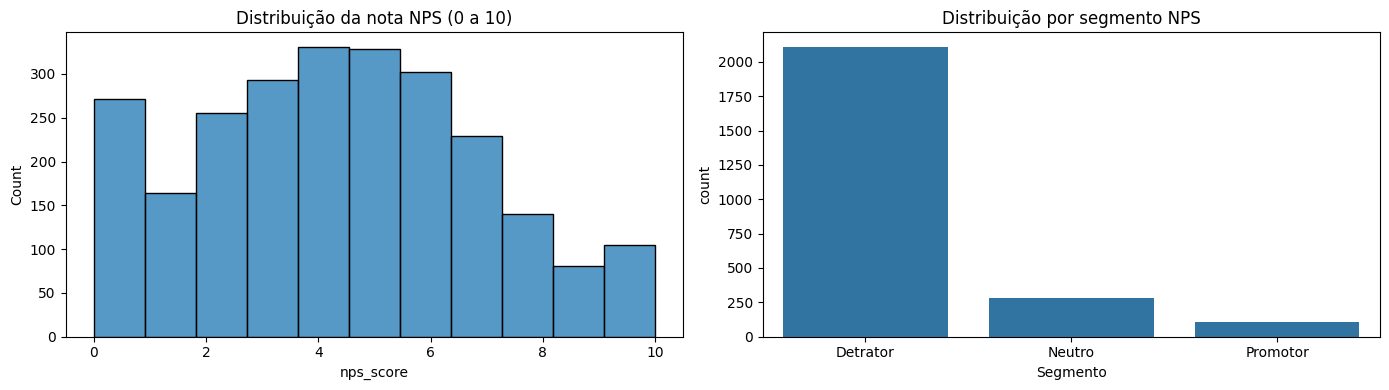


NPS consolidado da base: -80.0


In [118]:
def classificar_nps(nota):
    """Classifica a nota NPS nos três segmentos canônicos."""
    if nota >= 9:
        return 'Promotor'
    if nota >= 7:
        return 'Neutro'
    return 'Detrator'

df['nps_segmento'] = df['nps_score'].apply(classificar_nps)

# Distribuição da nota bruta
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(data=df, x='nps_score', bins=11, ax=axes[0])
axes[0].set_title('Distribuição da nota NPS (0 a 10)')
axes[0].set_xlabel('nps_score')

ordem_segmentos = ['Detrator', 'Neutro', 'Promotor']
sns.countplot(data=df, x='nps_segmento', order=ordem_segmentos, ax=axes[1])
axes[1].set_title('Distribuição por segmento NPS')
axes[1].set_xlabel('Segmento')

plt.tight_layout()
plt.show()

# NPS score
proporcoes = df['nps_segmento'].value_counts(normalize=True) * 100
nps_consolidado = proporcoes.get('Promotor', 0) - proporcoes.get('Detrator', 0)
print(f'\nNPS consolidado da base: {nps_consolidado:.1f}')

### 2.5 Analise de outliers por variavel metodo IQR

A abordagem adotada para a detecção de outliers na variável delivery_time_days consiste na utilização do método IQR (Interquartile Range). O IQR representa a diferença entre o terceiro quartil (Q3) e o primeiro quartil (Q1) da distribuição dos dados. Nesse contexto, são considerados outliers os valores que se encontram abaixo de Q1 - 1,5 × IQR ou acima de Q3 + 1,5 × IQR.

Após a análise, observou-se que os valores identificados permanecem dentro de um intervalo aceitável para a variável em questão, não havendo ocorrência de valores negativos ou inconsistentes. Além disso, verificou-se que a variável quality não exerce influência significativa sobre essa análise, não comprometendo os resultados obtidos.

DETECÇÃO DE OUTLIERS - delivery_delay_days (Método IQR)

Q1 (25º percentil):         1.00
Q3 (75º percentil):         3.00
IQR (Q3 - Q1):              2.00

Limite inferior:            -2.00
Limite superior:            6.00

Total de outliers:          17
Percentual de outliers:     0.68%


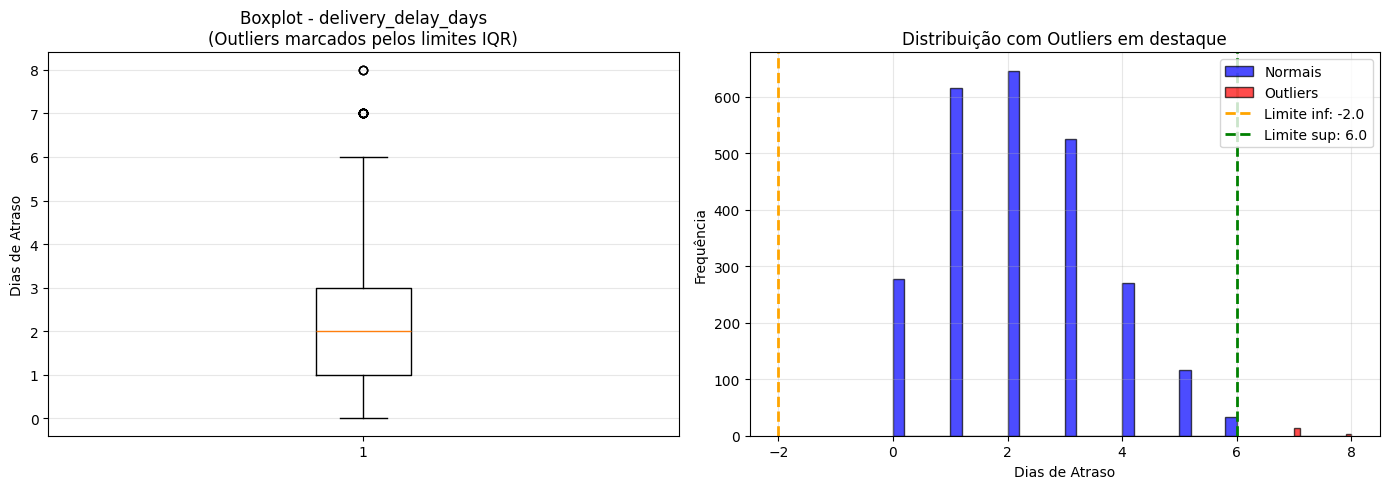


ESTATÍSTICAS DESCRITIVAS:

Dados Normais:
count    2483.000000
mean        2.153041
std         1.399010
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         6.000000
Name: delivery_delay_days, dtype: float64

Outliers:
count    17.000000
mean      7.176471
std       0.392953
min       7.000000
25%       7.000000
50%       7.000000
75%       7.000000
max       8.000000
Name: delivery_delay_days, dtype: float64


In [119]:
# Detecção de outliers - Método IQR para delivery_delay_days
def detectar_outliers_iqr(data, coluna):
    """
    Detecta outliers usando o método IQR.

    Parâmetros:
    - data: DataFrame
    - coluna: nome da coluna para análise

    Retorna:
    - máscara booleana indicando outliers
    - dicionário com estatísticas
    """
    Q1 = data[coluna].quantile(0.25)
    Q3 = data[coluna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = (data[coluna] < limite_inferior) | (data[coluna] > limite_superior)

    stats = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'total_outliers': outliers.sum(),
        'percentual_outliers': (outliers.sum() / len(data)) * 100
    }

    return outliers, stats

# Aplicar detecção IQR para delivery_delay_days
outliers_delivery, stats_delivery = detectar_outliers_iqr(df, 'delivery_delay_days')

# Adicionar coluna indicadora no dataframe
df['delivery_delay_outlier'] = outliers_delivery

# Exibir estatísticas
print("=" * 60)
print("DETECÇÃO DE OUTLIERS - delivery_delay_days (Método IQR)")
print("=" * 60)
print(f"\nQ1 (25º percentil):         {stats_delivery['Q1']:.2f}")
print(f"Q3 (75º percentil):         {stats_delivery['Q3']:.2f}")
print(f"IQR (Q3 - Q1):              {stats_delivery['IQR']:.2f}")
print(f"\nLimite inferior:            {stats_delivery['limite_inferior']:.2f}")
print(f"Limite superior:            {stats_delivery['limite_superior']:.2f}")
print(f"\nTotal de outliers:          {stats_delivery['total_outliers']}")
print(f"Percentual de outliers:     {stats_delivery['percentual_outliers']:.2f}%")
print("=" * 60)

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
axes[0].boxplot(df['delivery_delay_days'], vert=True)
axes[0].set_ylabel('Dias de Atraso')
axes[0].set_title('Boxplot - delivery_delay_days\n(Outliers marcados pelos limites IQR)')
axes[0].grid(axis='y', alpha=0.3)

# Distribuição com destaque para outliers
dados_normais = df[~outliers_delivery]['delivery_delay_days']
dados_outliers = df[outliers_delivery]['delivery_delay_days']

axes[1].hist(dados_normais, bins=30, alpha=0.7, label='Normais', color='blue', edgecolor='black')
axes[1].hist(dados_outliers, bins=10, alpha=0.7, label='Outliers', color='red', edgecolor='black')
axes[1].axvline(stats_delivery['limite_inferior'], color='orange', linestyle='--', linewidth=2, label=f'Limite inf: {stats_delivery["limite_inferior"]:.1f}')
axes[1].axvline(stats_delivery['limite_superior'], color='green', linestyle='--', linewidth=2, label=f'Limite sup: {stats_delivery["limite_superior"]:.1f}')
axes[1].set_xlabel('Dias de Atraso')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição com Outliers em destaque')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Comparação descritiva
print("\nESTATÍSTICAS DESCRITIVAS:")
print("\nDados Normais:")
print(df[~outliers_delivery]['delivery_delay_days'].describe())
print("\nOutliers:")
print(df[outliers_delivery]['delivery_delay_days'].describe())

---
## 3. Data Preparation

Limpeza, criação de features e separação em grupos lógicos de variáveis.

In [120]:
# Agrupamento lógico de variáveis — facilita análises bivariadas posteriores
variaveis_cliente = ['customer_age', 'customer_region', 'customer_tenure_months']
variaveis_pedido = ['order_value', 'items_quantity', 'discount_value', 'payment_installments']
variaveis_logistica = ['delivery_time_days', 'delivery_delay_days', 'freight_value', 'delivery_attempts']
variaveis_atendimento = ['customer_service_contacts', 'resolution_time_days', 'complaints_count']
variaveis_negocio = ['repeat_purchase_30d', 'csat_internal_score']

variaveis_numericas = (
    ['customer_age', 'customer_tenure_months']
    + variaveis_pedido + variaveis_logistica + variaveis_atendimento + variaveis_negocio
)

In [121]:
# Criação de features derivadas — hipóteses iniciais a validar

# Flag: entrega atrasada
df['flag_atraso'] = (df['delivery_delay_days'] > 0).astype(int)

# Flag: cliente teve contato com atendimento
df['flag_contato_atendimento'] = (df['customer_service_contacts'] > 0).astype(int)

# Flag: pedido com reclamação
df['flag_com_reclamacao'] = (df['complaints_count'] > 0).astype(int)

# Valor médio por item — proxy de ticket unitário
df['valor_medio_item'] = df['order_value'] / df['items_quantity'].replace(0, np.nan)

df[['flag_atraso', 'flag_contato_atendimento', 'flag_com_reclamacao', 'valor_medio_item']].head()

,flag_atraso,flag_contato_atendimento,flag_com_reclamacao,valor_medio_item
0,1,0,1,34.9325
1,1,0,1,229.4750
2,1,1,1,101.4120
3,1,1,1,151.0950
4,1,1,1,253.0600


---
## 4. Análise Exploratória (EDA)



Dicionário de rótulos legíveis para visualizações

In [122]:
# Mapeia o nome técnico da coluna para um rótulo amigável em português.
# Usado em títulos, eixos e legendas de gráficos. Mantém o código com nomes
# técnicos (exigência do pandas) mas entrega visualização profissional.
rotulos_variaveis = {
    'customer_id':               'ID do Cliente',
    'order_id':                  'ID do Pedido',
    'customer_age':              'Idade',
    'customer_region':           'Região',
    'customer_tenure_months':    'Tempo de Relacionamento (meses)',
    'order_value':               'Valor do Pedido (R$)',
    'items_quantity':            'Quantidade de Itens',
    'discount_value':            'Valor do Desconto (R$)',
    'payment_installments':      'Parcelas do Pagamento',
    'delivery_time_days':        'Tempo de Entrega (dias)',
    'delivery_delay_days':       'Atraso na Entrega (dias)',
    'freight_value':             'Valor do Frete (R$)',
    'delivery_attempts':         'Tentativas de Entrega',
    'customer_service_contacts': 'Contatos com Atendimento',
    'resolution_time_days':      'Tempo de Resolução (dias)',
    'complaints_count':          'Quantidade de Reclamações',
    'repeat_purchase_30d':       'Recompra em 30 dias',
    'csat_internal_score':       'Score CSAT Interno',
    'nps_score':                 'Nota NPS',
}

### 4.1 Análise univariada distribuição das variáveis numéricas

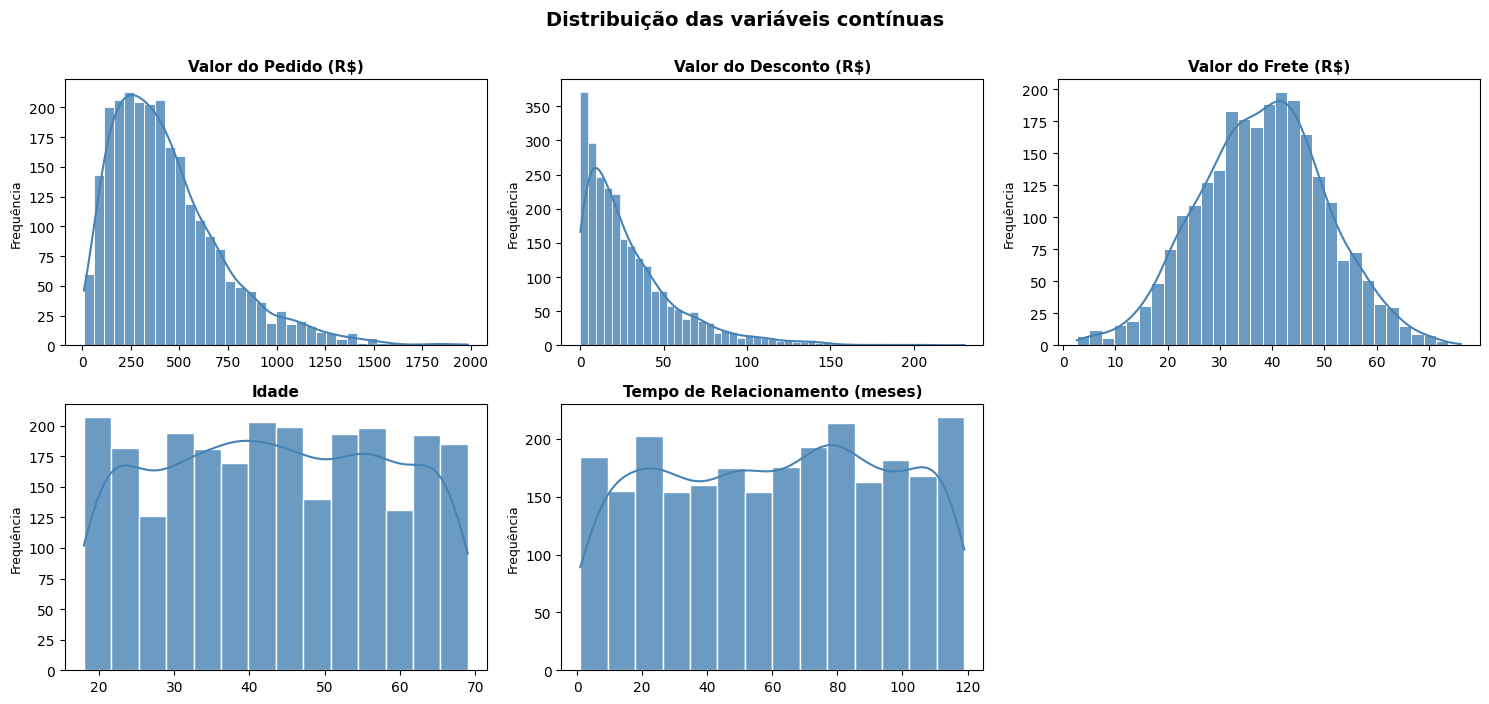

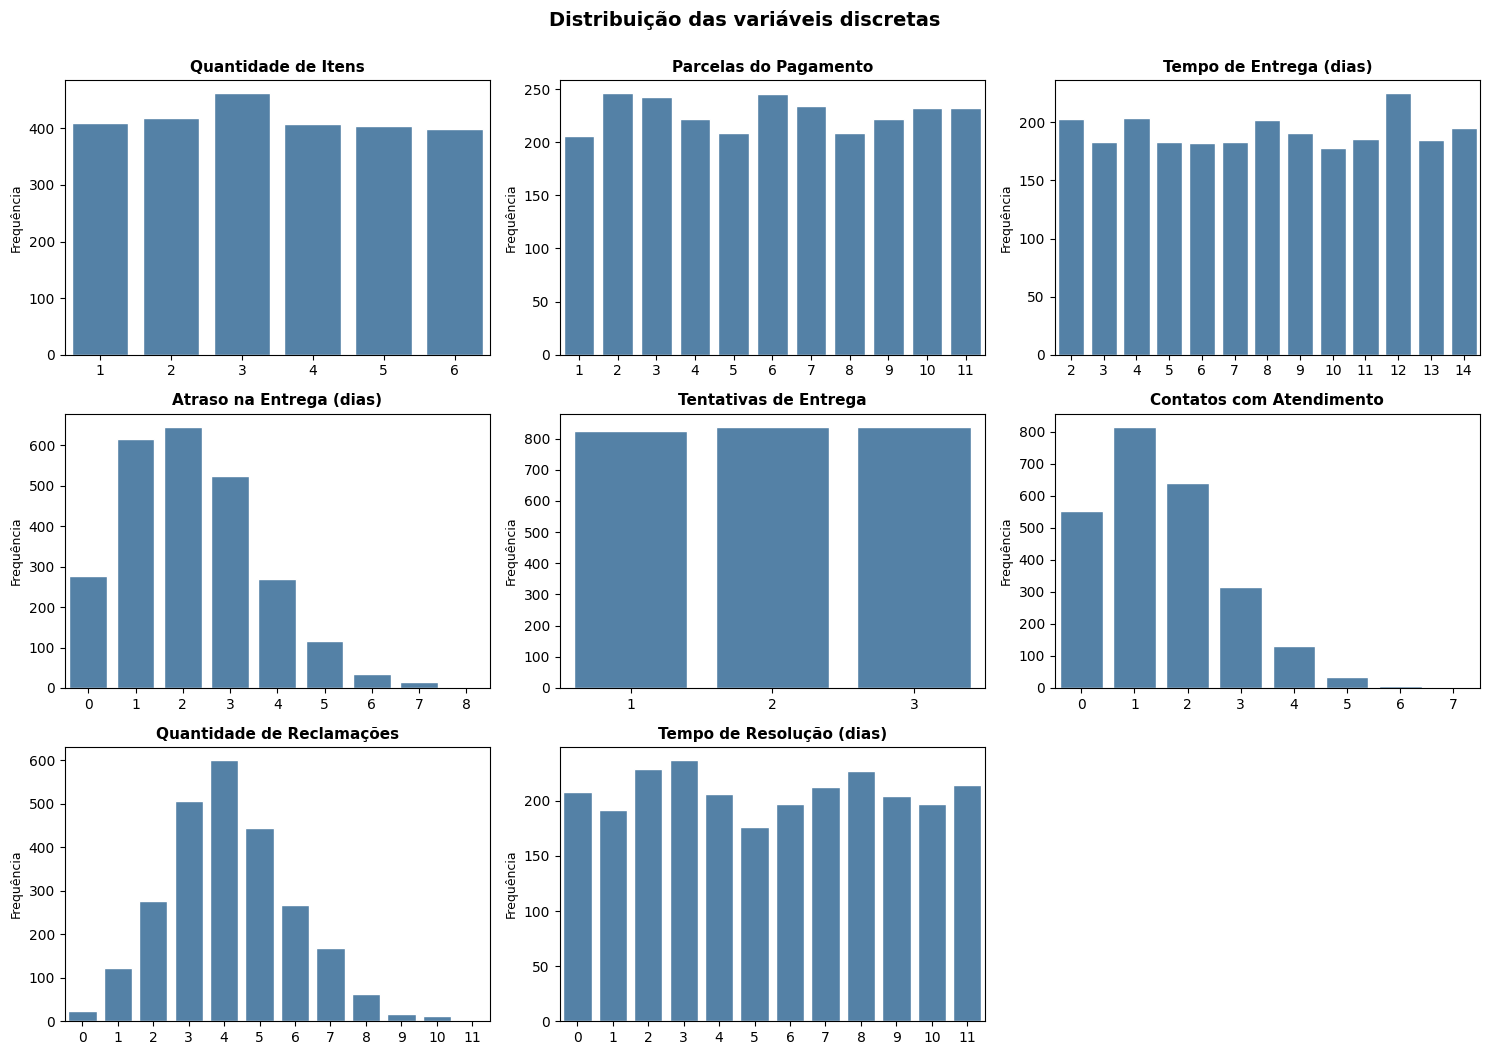

In [123]:
# ═══════════════════════════════════════════════════════════════
# Análise univariada: distribuição das variáveis numéricas
# Objetivo: Visualizar a forma da distribuição de cada variável,
#           respeitando sua natureza (contínua vs discreta).
#           KDE é aplicado apenas em variáveis contínuas, onde faz
#           sentido matemático. Variáveis discretas usam countplot.
# ═══════════════════════════════════════════════════════════════

# ─── Classificação das variáveis por natureza ────────────────────────────────
# Contínuas: valores reais sem restrição de granularidade
variaveis_continuas = [
    'order_value',
    'discount_value',
    'freight_value',
    'customer_age',           # Uniforme (base sintética), mas tecnicamente contínua
    'customer_tenure_months'  # Uniforme (base sintética), mas tecnicamente contínua
]

# Discretas: valores inteiros com poucas categorias distintas
variaveis_discretas = [
    'items_quantity',
    'payment_installments',
    'delivery_time_days',
    'delivery_delay_days',
    'delivery_attempts',
    'customer_service_contacts',
    'complaints_count',
    'resolution_time_days'
]

# Binárias: ignoradas aqui (já exibidas na análise de segmentos)
# 'repeat_purchase_30d', 'csat_internal_score'


# ─── Função auxiliar: grid de subplots com ocultação dinâmica ────────────────
def plotar_grid_distribuicoes(lista_variaveis, tipo_plot, titulo_geral):
    """Plota grid de histogramas ou countplots para uma lista de variáveis.

    Parâmetros:
        lista_variaveis (list): Nomes das colunas a plotar.
        tipo_plot (str): 'continua' (histplot+kde) ou 'discreta' (countplot).
        titulo_geral (str): Título da figura.
    """
    QUANTIDADE_COLUNAS_GRID = 3
    quantidade_variaveis = len(lista_variaveis)
    quantidade_linhas = int(np.ceil(quantidade_variaveis / QUANTIDADE_COLUNAS_GRID))

    figura, matriz_eixos = plt.subplots(
        nrows=quantidade_linhas,
        ncols=QUANTIDADE_COLUNAS_GRID,
        figsize=(15, 3.5 * quantidade_linhas)
    )
    eixos_planos = np.array(matriz_eixos).flatten()

    for indice, nome_variavel in enumerate(lista_variaveis):
        eixo_atual = eixos_planos[indice]

        # Busca o rótulo amigável; se não existir, usa o nome técnico como fallback
        rotulo_amigavel = rotulos_variaveis.get(nome_variavel, nome_variavel)

        if tipo_plot == 'continua':
            # Histograma + KDE faz sentido aqui (valores reais contínuos)
            sns.histplot(
                data=df,
                x=nome_variavel,
                kde=True,
                ax=eixo_atual,
                color='steelblue',
                edgecolor='white',
                alpha=0.8
            )
        else:
            # Countplot: barras discretas sem curva de densidade artificial
            sns.countplot(
                data=df,
                x=nome_variavel,
                ax=eixo_atual,
                color='steelblue',
                edgecolor='white'
            )

        eixo_atual.set_title(rotulo_amigavel, fontsize=11, fontweight='bold')
        eixo_atual.set_xlabel('')
        eixo_atual.set_ylabel('Frequência', fontsize=9)

    # Oculta subplots vazios (quando a quantidade não é múltipla do grid)
    for indice_vazio in range(quantidade_variaveis, len(eixos_planos)):
        eixos_planos[indice_vazio].set_visible(False)

    figura.suptitle(titulo_geral, fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()


# ─── Plot 1: Variáveis contínuas (histograma + KDE) ──────────────────────────
plotar_grid_distribuicoes(
    lista_variaveis=variaveis_continuas,
    tipo_plot='continua',
    titulo_geral='Distribuição das variáveis contínuas'
)

# ─── Plot 2: Variáveis discretas (countplot) ─────────────────────────────────
plotar_grid_distribuicoes(
    lista_variaveis=variaveis_discretas,
    tipo_plot='discreta',
    titulo_geral='Distribuição das variáveis discretas'
)

**Observações sobre as distribuições:**

As variáveis **contínuas financeiras** (`order_value`, `discount_value`) apresentam 
distribuição log-normal com cauda à direita — padrão típico de dados financeiros — 
enquanto `freight_value` é aproximadamente normal. As variáveis **demográficas** 
(`customer_age`, `customer_tenure_months`) têm distribuição praticamente uniforme, 
indicando amostragem sintética balanceada.

Entre as **discretas**, destacam-se três padrões: `delivery_delay_days` concentra-se 
em 1-3 dias com moda em 2 (apenas ~11% dos pedidos chegam sem atraso, reforçando o 
problema sistêmico de SLA); `customer_service_contacts` é decrescente com moda em 1 
contato; e `complaints_count` apresenta forma de sino centrada em 4, sugerindo que a 
variável registra incidentes operacionais do pedido, não reclamações formais do 
cliente. As variáveis `items_quantity`, `payment_installments`, `delivery_time_days`, 
`delivery_attempts` e `resolution_time_days` apresentam distribuição uniforme, 
característica de geração sintética controlada.

**Nota metodológica:** a uniformidade observada em diversas variáveis e o padrão 
atípico de `complaints_count` confirmam que o dataset é sintético. Isso preserva a 
validade da análise comparativa entre segmentos NPS (de natureza relativa), mas 
limita extrapolações sobre comportamento populacional real.

### 4.2 Análise bivariada cada variável vs. NPS

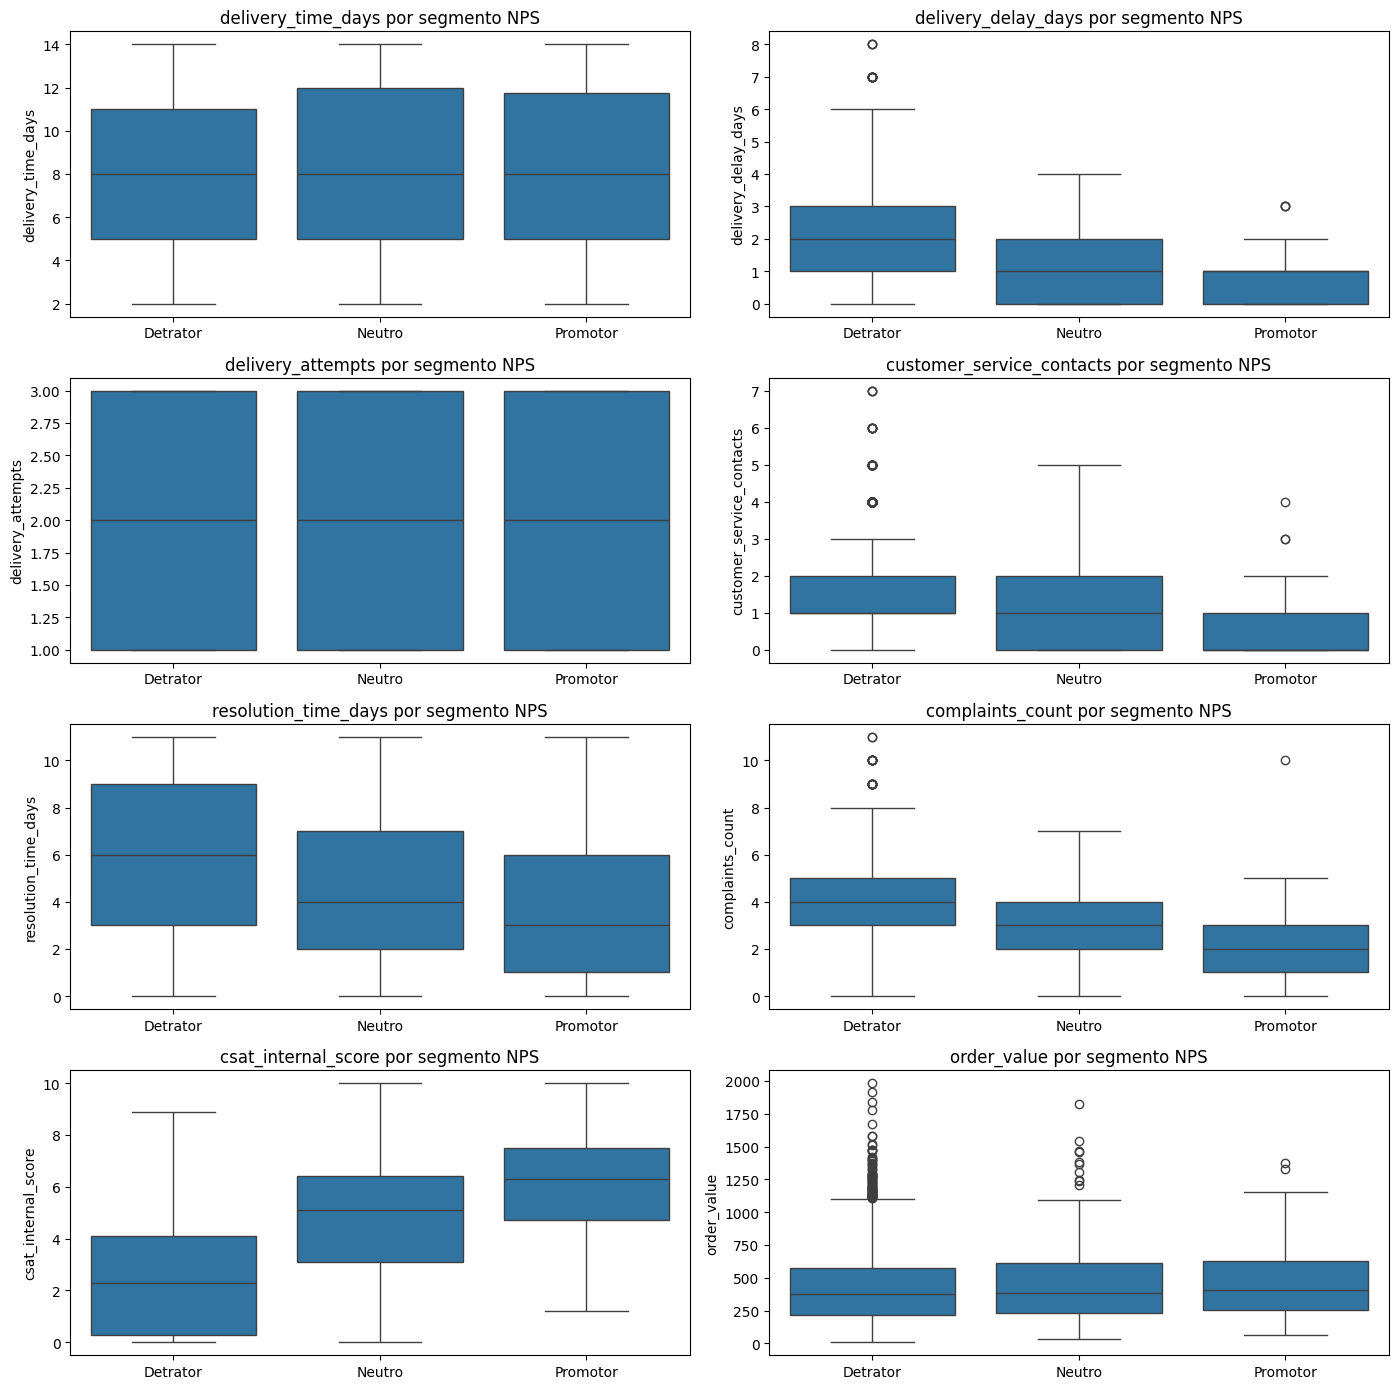

In [124]:
# Boxplots: como cada variável numérica se comporta nos três segmentos NPS
variaveis_para_comparar = [
    'delivery_time_days', 'delivery_delay_days', 'delivery_attempts',
    'customer_service_contacts', 'resolution_time_days', 'complaints_count',
    'csat_internal_score', 'order_value'
]

n_colunas = 2
n_linhas = int(np.ceil(len(variaveis_para_comparar) / n_colunas))
fig, axes = plt.subplots(n_linhas, n_colunas, figsize=(14, 3.5 * n_linhas))
axes = axes.flatten()

for i, coluna in enumerate(variaveis_para_comparar):
    sns.boxplot(data=df, x='nps_segmento', y=coluna, order=ordem_segmentos, ax=axes[i])
    axes[i].set_title(f'{coluna} por segmento NPS')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

### 4.3 Correlação entre variáveis numéricas e a target

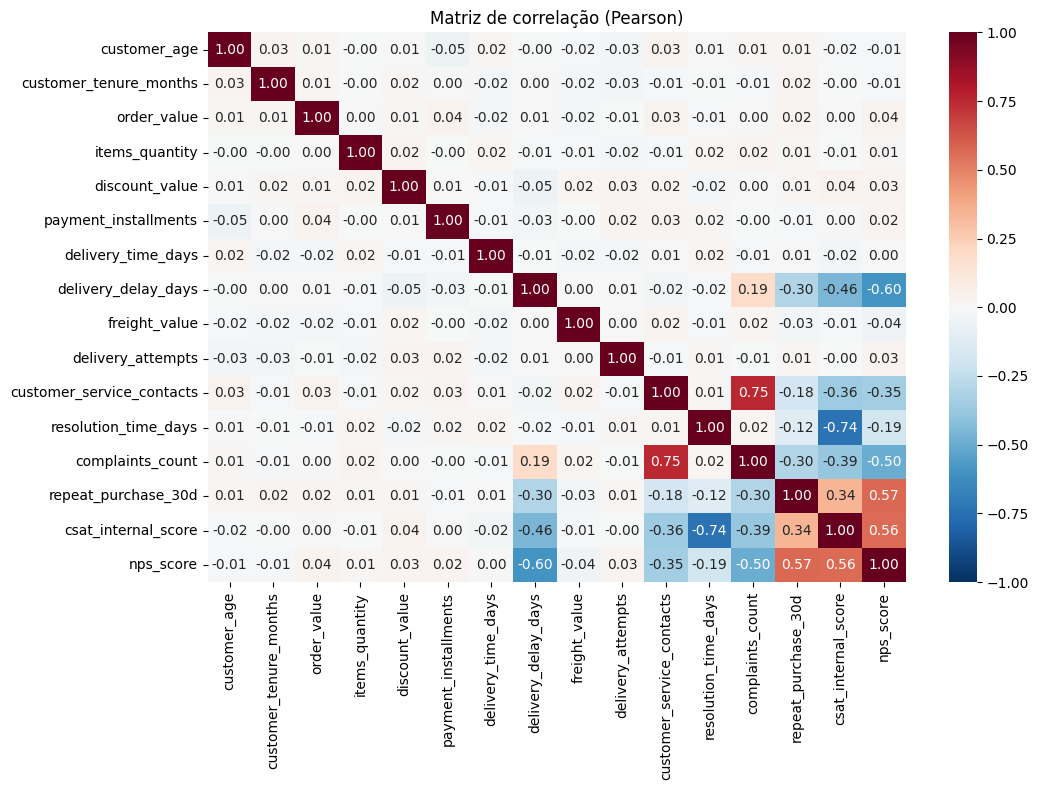


Top variáveis por correlação absoluta com nps_score:
delivery_delay_days          0.597260
repeat_purchase_30d          0.570324
csat_internal_score          0.563952
complaints_count             0.496800
customer_service_contacts    0.350845
resolution_time_days         0.191392
freight_value                0.041087
order_value                  0.036990
delivery_attempts            0.027680
discount_value               0.025104
payment_installments         0.023718
items_quantity               0.011468
customer_age                 0.009936
customer_tenure_months       0.009711
delivery_time_days           0.000925
Name: nps_score, dtype: float64


In [125]:
colunas_correlacao = variaveis_numericas + ['nps_score']
matriz_correlacao = df[colunas_correlacao].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    matriz_correlacao,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    vmin=-1, vmax=1
)
plt.title('Matriz de correlação (Pearson)')
plt.tight_layout()
plt.show()

# Ranking das variáveis mais correlacionadas com nps_score
correlacao_com_target = (
    matriz_correlacao['nps_score']
      .drop('nps_score')
      .abs()
      .sort_values(ascending=False)
)
print('\nTop variáveis por correlação absoluta com nps_score:')
print(correlacao_com_target)

### 4.4 Análise de detratores o que mais gera insatisfação?

In [126]:
# Comparar médias entre detratores e promotores para identificar gaps operacionais
perfil_por_segmento = (
    df.groupby('nps_segmento')[variaveis_numericas]
      .mean()
      .T
      .reindex(columns=ordem_segmentos)
)

perfil_por_segmento['gap_detrator_vs_promotor'] = (
    perfil_por_segmento['Detrator'] - perfil_por_segmento['Promotor']
)

perfil_por_segmento.sort_values('gap_detrator_vs_promotor', ascending=False)

nps_segmento,Detrator,Neutro,Promotor,gap_detrator_vs_promotor
complaints_count,4.442390,2.693950,2.272727,2.169662
resolution_time_days,5.694642,4.615658,3.700000,1.994642
delivery_delay_days,2.414889,1.053381,0.718182,1.696707
freight_value,38.298326,38.063381,37.050545,1.247781
customer_service_contacts,1.632053,1.007117,0.672727,0.959326
payment_installments,5.977715,6.277580,5.809091,0.168624
delivery_time_days,7.994310,8.263345,7.936364,0.057946
items_quantity,3.483167,3.313167,3.636364,-0.153196
delivery_attempts,1.997155,2.010676,2.154545,-0.157390
customer_age,43.403035,43.252669,43.627273,-0.224238


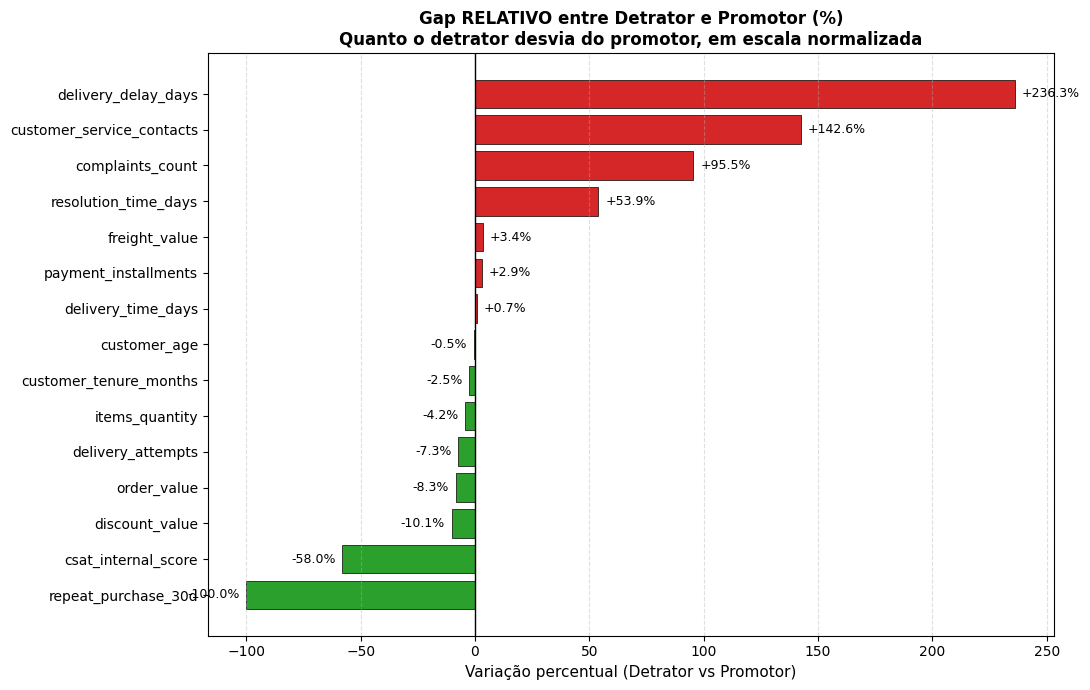


Gap percentual ordenado (do mais crítico ao mais protetor):
nps_segmento               Detrator  Promotor  gap_pct_detrator_vs_promotor
delivery_delay_days            2.41      0.72                        236.25
customer_service_contacts      1.63      0.67                        142.60
complaints_count               4.44      2.27                         95.47
resolution_time_days           5.69      3.70                         53.91
freight_value                 38.30     37.05                          3.37
payment_installments           5.98      5.81                          2.90
delivery_time_days             7.99      7.94                          0.73
customer_age                  43.40     43.63                         -0.51
customer_tenure_months        61.43     63.00                         -2.49
items_quantity                 3.48      3.64                         -4.21
delivery_attempts              2.00      2.15                         -7.31
order_value                

In [127]:
# Visualização: Gap RELATIVO entre Detratores e Promotores
# Objetivo: Comparar variáveis em escalas diferentes (R$, dias, contagens)
#           usando variação percentual ao invés de diferença absoluta.
#           Responde: "quanto o detrator desvia do promotor, em %?"

# ─── Cálculo do gap relativo (em %) ──────────────────────────────────────────
# Fórmula: ((Detrator - Promotor) / |Promotor|) * 100
# Uso de ABS no denominador evita inversão de sinal quando promotor é negativo
# replace(0, np.nan) protege contra divisão por zero (caso repeat_purchase_30d)
perfil_por_segmento['gap_pct_detrator_vs_promotor'] = (
    (perfil_por_segmento['Detrator'] - perfil_por_segmento['Promotor'])
    / perfil_por_segmento['Promotor'].abs().replace(0, np.nan)
) * 100

# ─── Preparação dos dados para o gráfico ─────────────────────────────────────
# Remove linhas com NaN (variáveis onde promotor = 0, sem cálculo possível)
gap_relativo = (
    perfil_por_segmento
    .dropna(subset=['gap_pct_detrator_vs_promotor'])
    .sort_values('gap_pct_detrator_vs_promotor')
)

# Cores semânticas (mesma lógica do gráfico anterior)
cores_barras = [
    '#d62728' if valor > 0 else '#2ca02c'
    for valor in gap_relativo['gap_pct_detrator_vs_promotor']
]

# ─── Gráfico de barras horizontais ───────────────────────────────────────────
plt.figure(figsize=(11, 7))
barras = plt.barh(
    gap_relativo.index,
    gap_relativo['gap_pct_detrator_vs_promotor'],
    color=cores_barras,
    edgecolor='black',
    linewidth=0.5
)

# Linha de referência no zero
plt.axvline(x=0, color='black', linewidth=1)

# Rótulos com o valor percentual em cada barra (facilita leitura)
for barra, valor in zip(barras, gap_relativo['gap_pct_detrator_vs_promotor']):
    largura = barra.get_width()
    posicao_x = largura + (3 if largura > 0 else -3)
    alinhamento = 'left' if largura > 0 else 'right'
    plt.text(
        posicao_x,
        barra.get_y() + barra.get_height() / 2,
        f'{valor:+.1f}%',
        va='center', ha=alinhamento, fontsize=9
    )

plt.title(
    'Gap RELATIVO entre Detrator e Promotor (%)\n'
    'Quanto o detrator desvia do promotor, em escala normalizada',
    fontsize=12, fontweight='bold'
)
plt.xlabel('Variação percentual (Detrator vs Promotor)', fontsize=11)
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Tabela complementar para consulta
print('\nGap percentual ordenado (do mais crítico ao mais protetor):')
print(
    perfil_por_segmento[['Detrator', 'Promotor', 'gap_pct_detrator_vs_promotor']]
    .sort_values('gap_pct_detrator_vs_promotor', ascending=False)
    .round(2)
    .to_string()
)

**Resultado:** os 4 maiores drivers de insatisfação são todos **operacionais e logísticos**atraso na entrega (+236%), contatos com o SAC (+143%), 
reclamações (+95%) e tempo de resolução (+54%). Variáveis demográficas (idade,tenure) e características do pedido (valor, parcelas, frete) apresentam gap inferior a 10%, sendo praticamente irrelevantes para discriminar detratores.
Destaque para o **paradoxo entrega vs atraso**: `delivery_time_days` tem gap de apenas +0,7% enquanto `delivery_delay_days` chega a +236%, revelando que **o cliente tolera entrega longa, mas não tolera atraso sobre o prometido** implicação direta para definição de SLAs realistas.

---

### 4.5 Análise por região

Analise NPS por Região

In [128]:
nps_por_regiao = (
    df.groupby('customer_region')
      .agg(
          qtd_pedidos=('order_id', 'count'),
          nps_medio=('nps_score', 'mean'),
          atraso_medio=('delivery_delay_days', 'mean'),
      )
      .sort_values('nps_medio', ascending=False)
)
nps_por_regiao

,qtd_pedidos,nps_medio,atraso_medio
customer_region,,,
Sul,521,4.490979,2.168906
Nordeste,485,4.421649,2.185567
Norte,506,4.382609,2.144269
Sudeste,520,4.373846,2.217308
Centro-Oeste,468,4.209829,2.222222


**Análise:** Distribuição de segmentos NPS por região  
**Objetivo:** Verificar se há regiões proporcionalmente mais detratoras independentemente do volume absoluto de pedidos.

In [129]:
# Tabela cruzada: % de cada segmento DENTRO de cada região
# normalize='index' garante que cada linha (região) some 100%
distribuicao_segmento_por_regiao = pd.crosstab(
    df['customer_region'],
    df['nps_segmento'],
    normalize='index'
) * 100

# Reordena as colunas para a sequência canônica (Detrator → Neutro → Promotor)
distribuicao_segmento_por_regiao = distribuicao_segmento_por_regiao[ordem_segmentos]

# Adiciona o volume absoluto de pedidos por região (contexto importante)
volume_por_regiao = df['customer_region'].value_counts()
distribuicao_segmento_por_regiao['Qtd_Pedidos'] = volume_por_regiao

# Calcula o "NPS regional" (% Promotor - % Detrator) — métrica oficial NPS
distribuicao_segmento_por_regiao['NPS_Regional'] = (
    distribuicao_segmento_por_regiao['Promotor']
    - distribuicao_segmento_por_regiao['Detrator']
)

# Ordena pelo NPS regional (melhor para pior)
distribuicao_segmento_por_regiao = distribuicao_segmento_por_regiao.sort_values(
    'NPS_Regional', ascending=False
)

print('Distribuição (%) de segmentos NPS por região:')
print(distribuicao_segmento_por_regiao.round(2).to_string())

Distribuição (%) de segmentos NPS por região:
nps_segmento     Detrator  Neutro  Promotor  Qtd_Pedidos  NPS_Regional
customer_region                                                       
Centro-Oeste        84.19   10.47      5.34          468        -78.85
Sul                 83.30   12.28      4.41          521        -78.89
Sudeste             83.65   11.92      4.42          520        -79.23
Nordeste            85.57   10.10      4.33          485        -81.24
Norte               85.18   11.26      3.56          506        -81.62


Não adianta focar esforço em "melhorar o Norte" ou "investir mais no Nordeste"
A causa raiz é interna ao processo (logística, atendimento, qualidade) **não geográfica**
Solução tem que ser horizontal e não regional

Os dados confirmam a hipótese de que os drivers reais estão nas variáveis operacionais (atraso, atendimento, reclamações).

---


### 4.6 Pontos de ruptura na experiência

Investigar **a partir de qual valor** uma variável operacional começa a derrubar a nota NPS de forma mais acentuada. Útil para definir SLAs internos baseados em dados.

In [130]:
# Exemplo: NPS médio por faixa de atraso
faixas_atraso = pd.cut(
    df['delivery_delay_days'],
    bins=[-0.1, 0, 1, 3, 7, 15, np.inf],
    labels=['Sem atraso', '1 dia', '2-3 dias', '4-7 dias', '8-15 dias', '15+ dias']
)

nps_por_faixa_atraso = (
    df.assign(faixa=faixas_atraso)
      .groupby('faixa', observed=True)
      .agg(qtd=('nps_score', 'count'), nps_medio=('nps_score', 'mean'))
)
nps_por_faixa_atraso

,qtd,nps_medio
faixa,,
Sem atraso,277,6.856679
1 dia,615,5.546179
2-3 dias,1171,4.067549
4-7 dias,434,2.011982
8-15 dias,3,0.000000


### 5.0 Modelos e predições

Vamos criar alguns modelos de regressão linear para prever a nota NPS. Com isso podemos tambem identificar quais fatores mais impactam a nota.

###5.1 Regressão linear Multipla - Limpando e treinando o modelo

Vamos recuperar a base e retrirar possiveis metricas que podem atrapalhar meu modelo:

customer_id e order_id - São identificadores únicos e não contêm informações preditivas sobre a satisfação do cliente. Usá-los adicionaria ruído ao modelo e não contribuiria para generalização.

csat_internal_score - Este campo é outra métrica de satisfação. Há um alto risco de data leakage, alem do que,usar um score de satisfação para prever outro score de satisfação pode fazer o modelo parecer muito bom, mas não seria útil para prever o NPS de clientes que ainda não tiveram essa métrica interna registrada.

repeat_purchase_30d - A recompra em 30 dias é mais uma consequência de uma experiência satisfatória e para prever o NPS de uma compra específica, a recompra subsequente não seria uma informação disponível naquele momento.

customer_region - Como ja evidenciado no EDA a regiao onde o cliente se encontra nao tem impacto no nps ou em outras variaveis que podem impactar o NPS.

In [131]:
# 1. Limpeza e Encoding

# 1.1 Recuperando dados brutos
df = pd.read_csv(CAMINHO_DADOS_BRUTOS)
df.head(5)

# 1.2 Retirando dados que nao influenciam nos modelos e nas notas, como id do cliente e id do pedido
# e retirando dados que podem atrapalhar na analise como recompra de produto, nps interno e regiao do pais.
df_tratado_modelo = df.drop(['customer_id', 'order_id', 'csat_internal_score', 'repeat_purchase_30d', 'customer_region'], axis=1)
df_tratado_modelo.head()

,customer_age,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,complaints_count
0,63,14,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,3
1,20,1,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,3
2,46,111,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,7
3,52,117,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,4
4,56,50,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,3


###5.1 Regressão linear Multipla - Limpando e treinando o modelo

Vamos separar nossa variavel alvo de NPS e separar nossos dados que serão utilizados para treinar o modelo VS os dados reais, assim sendo possivel fazer uma comparação entre o que o modelo gerou de predição com o registrado na base de dados



In [132]:
# 2. Preparando o modelo e treinando

# 2.1 Separar X e y, mantendo nossa variavel alvo no y
X = df_tratado_modelo.drop('nps_score', axis=1)
y = df_tratado_modelo['nps_score']

# 2.2 Treinando com regressão linear multipla
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 5.2 Regressão linear Multipla - Grafico de comparação do Preditivo vs Real

Para visualizarmos de uuma forma melhor, nada mais justo que um grafico correlacionando NPS reais da base com os preditivos do modelo.

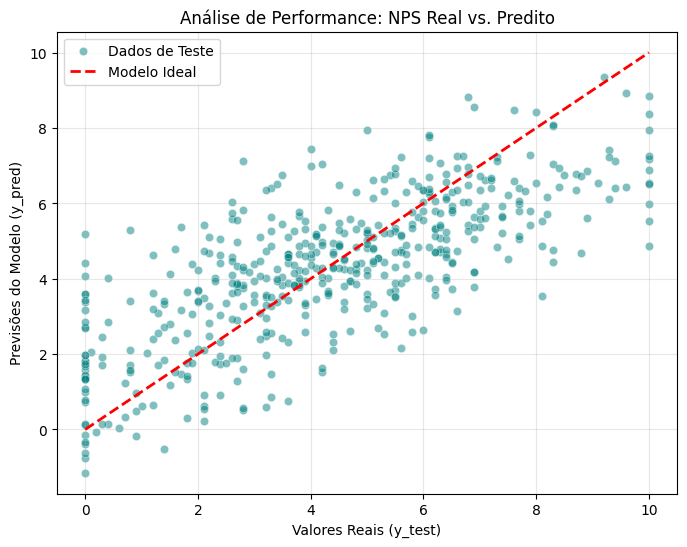

In [133]:
# 3. Comparando o resultado do modelo criado com dados reais de NPS

# 3.1 Gerar as predições do modelo final
y_pred = lin_reg.predict(X_test)

# 3.2 Plotar o gráfico base
plt.figure(figsize=(8, 6))

# Scatter plot: Real vs Predito
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='teal', label='Dados de Teste')

# Linha de Identidade, onde as predições se encontram
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', lw=2, label='Modelo Ideal')

plt.title('Análise de Performance: NPS Real vs. Predito')
plt.xlabel('Valores Reais (y_test)')
plt.ylabel('Previsões do Modelo (y_pred)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 5.3 Regressão linear Multipla - Calculando parametros de qualidade do modelo

Este bloco de código é essencial para avaliar a performance do seu modelo de regressão linear. Ele calcula quatro métricas chave para entender o quão bem o modelo está prevendo os valores reais do NPS:

In [134]:
# 4. Metricas para medir a qualidade do modelo

# 4.1 Calcular o MSE (Erro Médio Quadrático)
# Comparamos o Real (y_test) com a Previsão (lr_test_predictions) nos dados de teste
lin_mse = mean_squared_error(y_test, y_pred)

# 4.2 Calcular o RMSE (Raiz do Erro Médio Quadrático)
lin_rmse = np.sqrt(lin_mse)

# 4.3 Calcular o Erro Médio Absoluto
lin_mae = mean_absolute_error(y_test, y_pred)

# 4.4 Calcular o R²
lin_r2 = r2_score(y_test, y_pred)

print(f"MSE (Teste): {lin_mse:.4f}")
print(f"RMSE (Teste): {lin_rmse:.4f}")
print(f"MAE (Teste): {lin_mae:.4f}")
print(f"R2 (Teste): {lin_r2:.4f}")

MSE (Teste): 2.8569
RMSE (Teste): 1.6902
MAE (Teste): 1.3382
R2 (Teste): 0.5479


### 5.4 Regressão linear Multipla - Analisando resultados

Um R² (Coeficiente de Determinação) de 0.5479 significa que aproximadamente 54.79% da variabilidade no NPS pode ser explicada pelo seu modelo de regressão linear e pelas variáveis independentes que você incluiu.

Um R² acima de 0.5 (ou seja, mais da metade da variância explicada) muitas vezes é considerado um bom ponto de partida e indica que o modelo tem um poder preditivo moderado e pode fornecer insights úteis.

### 5.5 Regressão linear Multipla - Analisando coeficientes de importancia

Coeficientes de importancia podem gerar insights valiosos sobre a importância de cada variável no modelo.

In [135]:
# 5. Coeficientes de importancia no modelo para o calculo do NPS

coeficientes = pd.DataFrame(lin_reg.coef_, X.columns, columns=['Coeficiente']).sort_values(by='Coeficiente', ascending=False)
print(coeficientes)

                           Coeficiente
delivery_attempts             0.116175
payment_installments          0.012284
items_quantity                0.011224
delivery_time_days            0.008105
customer_age                  0.000431
order_value                   0.000406
discount_value               -0.001511
customer_tenure_months       -0.001629
freight_value                -0.008552
resolution_time_days         -0.148197
customer_service_contacts    -0.341910
complaints_count             -0.380133
delivery_delay_days          -0.944231


### 5.6 Regressão linear Multipla - Analisando visualmente os coeficientes

Coeficientes de importancia podem gerar insights valiosos sobre a importância de cada variável no modelo como ja explicado na ultima parte, logo podemos trazer ele pro grafico para termos uma dimensão maior de sua importancia

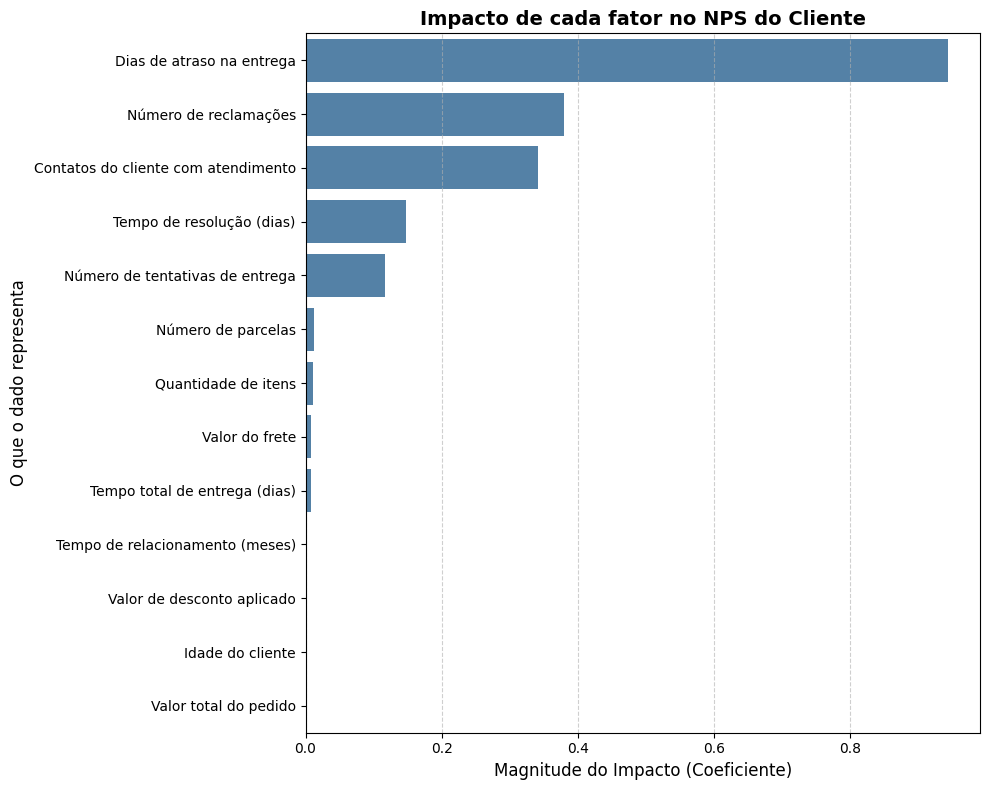

In [136]:
# 6. Impacto de cada fator no NPS do cliente.

# 6.1 Preparar os dados de importância
importancia = pd.DataFrame({
    'coluna': X.columns,
    'Impacto': abs(lin_reg.coef_)
}).sort_values(by='Impacto', ascending=False)

# 6.2 Mapear as descrições usando o dicionario
importancia['descricao'] = importancia['coluna'].apply(
    lambda x: dicionario_dados.get(x, x)
)

# 6.3  Criar o gráfico apontando a variavel com mais impacto
plt.figure(figsize=(10, 8))
sns.barplot(data=importancia, x='Impacto', y='descricao', color='steelblue')

plt.title('Impacto de cada fator no NPS do Cliente', fontsize=14, fontweight='bold')
plt.xlabel('Magnitude do Impacto (Coeficiente)', fontsize=12)
plt.ylabel('O que o dado representa', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 5.7 Regressão linear Multipla - Analisando visualmente os coeficientes

Como podemos verificar no grafico o numero de reclamação e o tempo de resolução são os maiores ofensivos pra determinarmos o NPS no modelo criado, porem precisamos identificar quais coeficientes tem mais importancia no NPS positivo e negativo do nosso modelo

### 5.8 Análise dos Coeficientes do Modelo

Vamos visualizar os coeficientes do modelo de regressão linear para entender o impacto individual de cada variável no NPS. Um coeficiente positivo indica que, à medida que a variável aumenta, o NPS tende a aumentar. Um coeficiente negativo indica o contrário.

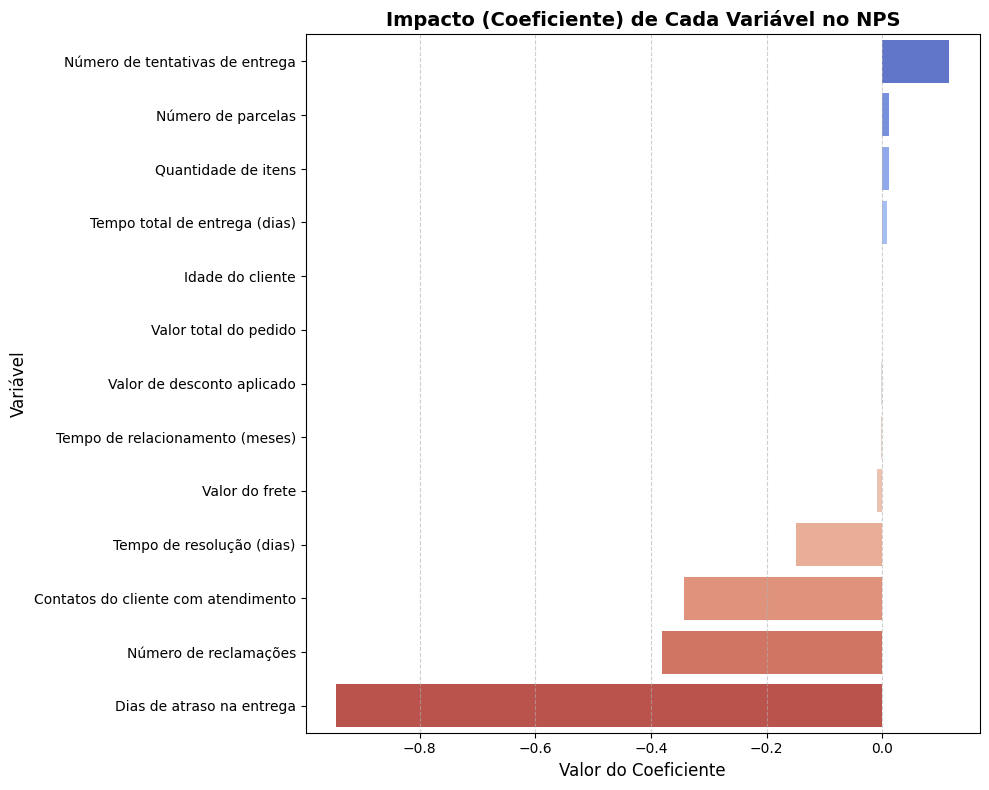

In [137]:
coeficientes['descricao'] = coeficientes.index.map(dicionario_dados.get)

plt.figure(figsize=(10, 8))
sns.barplot(x='Coeficiente', y='descricao', hue='descricao', data=coeficientes, palette='coolwarm', legend=False)

plt.title('Impacto (Coeficiente) de Cada Variável no NPS', fontsize=14, fontweight='bold')
plt.xlabel('Valor do Coeficiente', fontsize=12)
plt.ylabel('Variável', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 5.9 Conclusão do modelo

Com base nas análises exploratórias e no modelo de Regressão podemos tirar as algumas conclusões e proximos passos:

- Objetivo do Modelo: O modelo foi desenvolvido com o propósito de prever a nota nps_score dos clientes, o que é fundamental para antecipar clientes com risco de se tornarem detratores.

- Performance do Modelo (R²): O modelo alcançou um R² de aproximadamente 0.5479, o que indica que cerca de 54.79% da variabilidade no nps_score é explicada pelas variáveis incluídas no modelo.

- Maiores Impactos Negativos: As variáveis com os maiores coeficientes negativos são dias de atraso na entrega, número de reclamações, contatos com o atendimento ao cliente e tempo de resolução. Isso reforça a importância de uma entrega pontual, de evitar reclamações e de oferecer um atendimento eficiente e rápido.

- Impactos Positivos: número de tentativas de entrega, foi a variável com maior coeficiente positivo. Isso pode indicar que, em alguns casos, a insistência na entrega, mesmo após a primeira tentativa, pode ser percebida positivamente ou garantir que o cliente receba seu produto, evitando uma experiência negativa.
    
    
- Insights para o Negócio: Os resultados confirmam que a experiência logística e o atendimento ao cliente são fatores críticos para a satisfação. Reduzir atrasos, minimizar reclamações e otimizar o tempo de resolução de problemas são ações que provavelmente terão um impacto positivo significativo no NPS.
